# MODI-HChar: Hybrid Deep Learning for Historical Script Recognition
### Phases 1–5: Data Setup → Preprocessing → Model Architecture → Incremental Training → Evaluation
---

## 🔧 Environment Setup

In [3]:
# Install required libraries
%pip install -q numpy tensorflow opencv-python-headless scikit-image scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import zipfile
import shutil
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import InceptionV3, ResNet152, InceptionResNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from skimage.filters import threshold_otsu, threshold_sauvola
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.21.0
GPU available: []


---
## Phase 1: Data Acquisition & Structural Setup

### 1.1 Extract MODI-HChar Dataset

In [2]:
# ─── CONFIGURE PATHS ───────────────────────────────────────────────────────────
ZIP_PATH     = "archive.zip"   # <-- Update this path
BASE_DIR     = Path("./MODI_HChar")
DATASET_DIR  = BASE_DIR / "raw"
SPLIT_DIR    = BASE_DIR / "split"
PROC_DIR     = BASE_DIR / "processed"
MODELS_DIR   = BASE_DIR / "models"
RESULTS_DIR  = BASE_DIR / "results"

for d in [DATASET_DIR, SPLIT_DIR, PROC_DIR, MODELS_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ─── EXTRACT ───────────────────────────────────────────────────────────────────
if not any(DATASET_DIR.iterdir()) if DATASET_DIR.exists() else True:
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(DATASET_DIR)
    print("Extraction complete.")
else:
    print("Dataset already extracted.")

# Show top-level structure
for p in sorted(DATASET_DIR.rglob("*"))[:20]:
    print(p.relative_to(DATASET_DIR))

Dataset already extracted.
consonants
consonants\b
consonants\b\b1.jpg
consonants\b\b10.jpg
consonants\b\b100.jpg
consonants\b\b1000.jpg
consonants\b\b10000.jpg
consonants\b\b10001.jpg
consonants\b\b10002.jpg
consonants\b\b10003.jpg
consonants\b\b10004.jpg
consonants\b\b10005.jpg
consonants\b\b10006.jpg
consonants\b\b10007.jpg
consonants\b\b10008.jpg
consonants\b\b10009.jpg
consonants\b\b1001.jpg
consonants\b\b10010.jpg
consonants\b\b10011.jpg
consonants\b\b10012.jpg


### 1.2 Define 57-Class Map

In [4]:
# ─── 57-CLASS DEFINITION ───────────────────────────────────────────────────────
DIGITS = [
    '0','1','2','3','4','5','6','7','8','9'
]  # 10 digit classes

VOWELS = [
    "a", "aa", "ah", "ai", "am",
    "e", "i", "ii", "o", "oo", "ou", "u"
]  # 12 vowel classes

CONSONANTS = [
    "b", "bh", "ch", "chh", "d", "dh", "dha", "dyn",
    "g", "gh", "h", "ja", "jh", "k", "kh", "ksh",
    "l", "lh", "m", "n", "nn", "p", "ph", "r",
    "s", "sh", "shr", "ta", "th", "tha", "thh",
    "thha", "tr", "v", "y"
]  # 35 consonant classes

ALL_CLASSES = DIGITS + VOWELS + CONSONANTS
NUM_CLASSES = len(ALL_CLASSES)   # Must equal 57
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(ALL_CLASSES)}
IDX_TO_CLASS = {idx: cls for cls, idx in CLASS_TO_IDX.items()}

# Subgroup index ranges
DIGIT_INDICES     = list(range(0,  10))
VOWEL_INDICES     = list(range(10, 22))
CONSONANT_INDICES = list(range(22, 57))

print(f"Total classes : {NUM_CLASSES}")
print(f"Digits        : {len(DIGITS)}")
print(f"Vowels        : {len(VOWELS)}")
print(f"Consonants    : {len(CONSONANTS)}")
print("\nClass map sample:", {k: CLASS_TO_IDX[k] for k in ALL_CLASSES[:5]})

Total classes : 57
Digits        : 10
Vowels        : 12
Consonants    : 35

Class map sample: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}


### 1.3 Data Partitioning (80 / 20 split)

In [5]:
TRAIN_RATIO = 0.80
TEST_RATIO  = 0.20
RANDOM_SEED = 42

# ─── MAP FOLDER NAMES TO CLASS LABELS ─────────────────────────────────────────
# Adjust these subfolder names if the zip uses different naming conventions
CATEGORY_MAP = {
    "digits":     DIGITS,
    "vowels":     VOWELS,
    "consonants": CONSONANTS,
}

def partition_dataset(dataset_dir, split_dir, train_ratio=0.8, seed=42):
    """Walk dataset_dir, collect image paths per class, split, copy to split_dir."""
    random.seed(seed)
    stats = defaultdict(lambda: {'train': 0, 'test': 0})

    for category, class_list in CATEGORY_MAP.items():
        cat_path = Path(dataset_dir) / category
        if not cat_path.exists():
            print(f"WARNING: '{cat_path}' not found — skipping.")
            continue

        for cls_name in class_list:
            cls_src = cat_path / cls_name
            if not cls_src.exists():
                print(f"  Skipping missing class folder: {cls_src}")
                continue

            images = sorted([
                p for p in cls_src.iterdir()
                if p.suffix.lower() in ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
            ])
            random.shuffle(images)

            split_at = int(len(images) * train_ratio)
            splits = {'train': images[:split_at], 'test': images[split_at:]}

            for subset, files in splits.items():
                dst_dir = Path(split_dir) / subset / cls_name
                dst_dir.mkdir(parents=True, exist_ok=True)
                for f in files:
                    shutil.copy2(f, dst_dir / f.name)
                stats[cls_name][subset] = len(files)

    return stats

# Run partitioning (skip if already done)
if not (SPLIT_DIR / "train").exists():
    print("Partitioning dataset — this may take a few minutes...")
    stats = partition_dataset(DATASET_DIR, SPLIT_DIR, TRAIN_RATIO, RANDOM_SEED)
    total_train = sum(v['train'] for v in stats.values())
    total_test  = sum(v['test']  for v in stats.values())
    print(f"\nPartitioning complete.")
    print(f"  Training images : {total_train:,}")
    print(f"  Testing images  : {total_test:,}")
else:
    print("Split already exists — skipping partitioning.")

Split already exists — skipping partitioning.


---
## Phase 2: Pre-Processing & Standardization

### 2.1 Define Binarization Pipelines

In [13]:
TARGET_SIZE = (256, 256)

# ─── BINARIZATION FUNCTIONS ────────────────────────────────────────────────────

def binarize_otsu(gray: np.ndarray) -> np.ndarray:
    """Global Otsu thresholding."""
    thresh = threshold_otsu(gray)
    binary = (gray > thresh).astype(np.float32)
    return binary

def binarize_sauvola(gray: np.ndarray, window_size: int = 25) -> np.ndarray:
    """Local Sauvola adaptive thresholding — best for degraded historical docs."""
    thresh = threshold_sauvola(gray, window_size=window_size)
    binary = (gray > thresh).astype(np.float32)
    return binary

def binarize_tozero(gray: np.ndarray, threshold: float = 0.85) -> np.ndarray:
    """Zero out all pixels below threshold (suppresses grey background)."""
    binary = np.where(gray < threshold, 0.0, gray)
    return binary.astype(np.float32)

BINARIZATION_METHODS = {
    "otsu":    binarize_otsu,
    "sauvola": binarize_sauvola,
    "tozero":  binarize_tozero,
}

def preprocess_image(img_path: str, method: str = "otsu") -> np.ndarray:
    """
    Full preprocessing pipeline:
      1. Load as grayscale
      2. Resize to 256x256
      3. Binarize with selected method
      4. Stack to 3-channel (for ImageNet-pretrained models)
      5. Normalize to [0, 1]
    """
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Cannot load: {img_path}")

    # Step 1 — resize
    img_resized = cv2.resize(img, TARGET_SIZE, interpolation=cv2.INTER_CUBIC)

    # Step 2 — normalize to [0,1] float before binarization
    img_norm = img_resized.astype(np.float32) / 255.0

    # Step 3 — binarize
    fn = BINARIZATION_METHODS[method]
    img_bin = fn(img_norm)

    # Step 4 — stack to 3 channels
    img_3ch = np.stack([img_bin, img_bin, img_bin], axis=-1)  # (256,256,3)

    return img_3ch  # values in [0, 1]

### 2.2 Visualize Preprocessing Effects

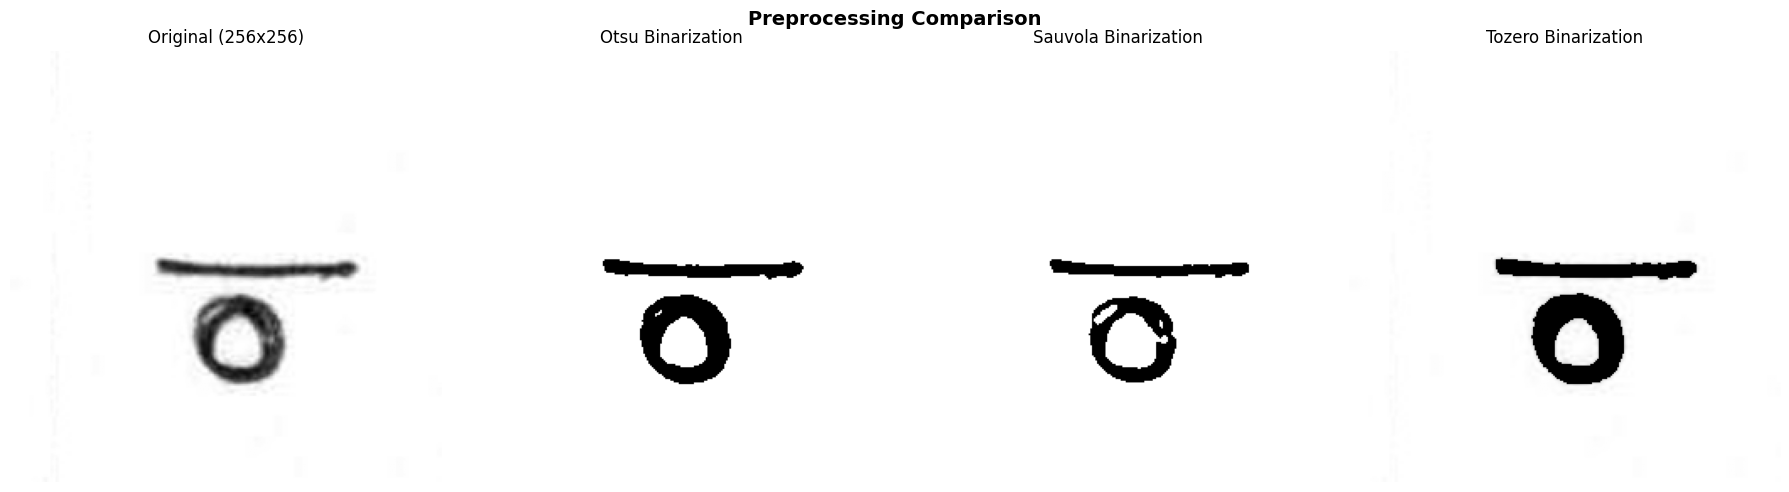

Sample class: 0


In [14]:
# Pick a sample image to visualize all three methods
sample_images = list((SPLIT_DIR / "train").rglob("*.jpg"))[:1]
# if not sample_images:
#     sample_images = list((SPLIT_DIR / "train").rglob("*.png"))[:1]

if sample_images:
    sample_path = sample_images[0]
    original = cv2.imread(str(sample_path), cv2.IMREAD_GRAYSCALE)
    original_resized = cv2.resize(original, TARGET_SIZE, interpolation=cv2.INTER_CUBIC)

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    fig.suptitle("Preprocessing Comparison", fontsize=14, fontweight='bold')

    axes[0].imshow(original_resized, cmap='gray')
    axes[0].set_title("Original (256x256)")
    axes[0].axis('off')

    for ax, method in zip(axes[1:], ['otsu', 'sauvola', 'tozero']):
        processed = preprocess_image(sample_path, method)
        ax.imshow(processed[:, :, 0], cmap='gray')
        ax.set_title(f"{method.capitalize()} Binarization")
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "preprocessing_comparison.png", dpi=150)
    plt.show()
    print(f"Sample class: {sample_path.parent.name}")
else:
    print("No sample images found — run Phase 1 first.")

### 2.3 TensorFlow Data Pipeline with On-the-fly Preprocessing

In [22]:
BATCH_SIZE   = 32
IMG_SIZE     = 256
AUTOTUNE     = tf.data.AUTOTUNE

def build_tf_dataset(
    split_root: Path,
    class_list: list,
    binarize_method: str = "tozero",
    batch_size: int = BATCH_SIZE,
    shuffle: bool = True,
    augment: bool = False,
) -> tf.data.Dataset:
    """
    Build a tf.data.Dataset for a given split, restricted to `class_list`.
    Labels are mapped using CLASS_TO_IDX for consistent 57-class indexing.
    """
    file_paths, labels = [], []

    MAX_IMAGES_PER_CLASS = 20  # ← add this cap

    for cls in class_list:
        cls_dir = split_root / cls
        if not cls_dir.exists():
            continue
        imgs = [
            str(p) for p in cls_dir.iterdir()
            if p.suffix.lower() in ('.jpg')
        ]
        if len(imgs) > MAX_IMAGES_PER_CLASS:
            random.shuffle(imgs)
            imgs = imgs[:MAX_IMAGES_PER_CLASS]
        for img_path in imgs:
            file_paths.append(img_path)
            labels.append(CLASS_TO_IDX[cls])

    print(f"  [{split_root.name}] {len(file_paths):,} images | "
          f"{len(set(labels))} classes | method={binarize_method}")

    def load_and_preprocess(path, label):
        img = tf.py_function(
            lambda p: preprocess_image(p.numpy().decode(), binarize_method),
            [path], tf.float32
        )
        img.set_shape([IMG_SIZE, IMG_SIZE, 3])
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(file_paths), 10000), seed=RANDOM_SEED)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)

    if augment:
        augmentation = keras.Sequential([
            layers.RandomRotation(0.05),
            layers.RandomTranslation(0.05, 0.05),
            layers.RandomZoom(0.05),
        ])
        ds = ds.map(lambda x, y: (augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)

    return ds.batch(batch_size).prefetch(AUTOTUNE)

print("Dataset builder defined.")

Dataset builder defined.


---
## Phase 3: Model Architecture Configuration

### 3.1 Hybrid Model Builder

In [31]:
BASE_MODELS = {
    "InceptionV3":        InceptionV3,
    "ResNet152":          ResNet152,
    "InceptionResNetV2":  InceptionResNetV2,
}

def build_hybrid_model(
    base_model_name: str = "ResNet152",
    num_classes: int = NUM_CLASSES,
    input_shape: tuple = (256, 256, 3),
    freeze_base: bool = True,
    freeze_up_to: int = None,   # freeze only first N layers
) -> Model:
    """
    Builds the hybrid architecture from Section 4 of the paper:

    Base (InceptionV3 / ResNet152 / InceptionResNetV2, ImageNet weights)
      └─ Extra Conv2D (64 filters, 3x3, ReLU)
      └─ Extra Conv2D (128 filters, 3x3, ReLU)
      └─ GlobalAveragePooling2D
      └─ Dense 1024  → ReLU
      └─ Dropout 0.3
      └─ Dense 512   → ReLU
      └─ Dropout 0.2
      └─ Dense 256   → ReLU
      └─ Dense num_classes → Softmax
    """
    # ── Base engine ──────────────────────────────────────────────────────────
    base_cls = BASE_MODELS[base_model_name]
    base = base_cls(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape,
    )

    if freeze_base:
        if freeze_up_to is not None:
            for layer in base.layers[:freeze_up_to]:
                layer.trainable = False
            for layer in base.layers[freeze_up_to:]:
                layer.trainable = True
        else:
            base.trainable = False

    # ── Custom top ───────────────────────────────────────────────────────────
    x = base.output

    # Extra convolution layers
    x = layers.Conv2D(64,  3, padding='same', activation='relu',
                      name='extra_conv_64')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu',
                      name='extra_conv_128')(x)
    x = layers.BatchNormalization()(x)

    # Pooling
    x = layers.GlobalAveragePooling2D()(x)

    # Dense stack with dropout
    x = layers.Dense(1024, activation='relu', name='dense_1024')(x)
    x = layers.Dropout(0.3, name='dropout_0_3')(x)

    x = layers.Dense(512,  activation='relu', name='dense_512')(x)
    x = layers.Dropout(0.2, name='dropout_0_2')(x)

    x = layers.Dense(256,  activation='relu', name='dense_256')(x)

    # Output
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inputs=base.input, outputs=outputs,
                  name=f"MODI_{base_model_name}")
    return model


# Quick sanity check
test_model = build_hybrid_model("ResNet152", NUM_CLASSES)
test_model.summary(line_length=100, show_trainable=True)
print(f"\nOutput shape: {test_model.output_shape}")
del test_model   # free memory

234698864/234698864 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step


Model: "MODI_ResNet152"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape         ┃       Param # ┃ Connected to         ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer_9            │ (None, 256, 256, 3)  │             0 │ -                    │    -    │
│ (InputLayer)             │                      │               │                      │         │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ conv1_pad                │ (None, 262, 262, 3)  │             0 │ input_layer_9[0][0]  │    -    │
│ (ZeroPadding2D)          │                      │               │                      │         │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ conv1_conv (Conv2D)      │ (None, 128, 128, 64) │         9,472 │ conv1_pad[0][0]      │    N    │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ conv1_bn                 │ (None, 128, 128, 64) │           256 │ conv1_conv[0][0]     │    N    │
│ (BatchNormalization)     │                      │               │                      │         │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ conv1_relu (Activation)  │ (None, 128, 128, 64) │             0 │ conv1_bn[0][0]       │    -    │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ pool1_pad                │ (None, 130, 130, 64) │             0 │ conv1_relu[0][0]     │    -    │
│ (ZeroPadding2D)          │                      │               │                      │         │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ pool1_pool               │ (None, 64, 64, 64)   │             0 │ pool1_pad[0][0]      │    -    │
│ (MaxPooling2D)           │                      │               │                      │         │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ conv2_block1_1_conv      │ (None, 64, 64, 64)   │         4,160 │ pool1_pool[0][0]     │    N    │
│ (Conv2D)                 │                      │               │                      │         │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ conv2_block1_1_bn        │ (None, 64, 64, 64)   │           256 │ conv2_block1_1_conv… │    N    │
│ (BatchNormalization)     │                      │               │                      │         │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ conv2_block1_1_relu      │ (None, 64, 64, 64)   │             0 │ conv2_block1_1_bn[0… │    -    │
│ (Activation)             │                      │               │                      │         │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ conv2_block1_2_conv      │ (None, 64, 64, 64)   │        36,928 │ conv2_block1_1_relu… │    N    │
│ (Conv2D)                 │                      │               │                      │         │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ conv2_block1_2_bn        │ (None, 64, 64, 64)   │           256 │ conv2_block1_2_conv… │    N    │
│ (BatchNormalization)     │                      │               │                      │         │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ conv2_block1_2_relu      │ (None, 64, 64, 64)   │             0 │ conv2_block1_2_bn[0… │    -    │
│ (Activation)             │                      │               │                      │         │
├──────────────────────────┼──────────────────────┼──────────

 Total params: 60,428,153 (230.52 MB)

 Trainable params: 2,056,825 (7.85 MB)

 Non-trainable params: 58,371,328 (222.67 MB)


Output shape: (None, 57)


---
## Phase 4: Incremental Training Strategy

### 4.1 Shared Training Utilities

In [32]:
def compile_model(model: Model, learning_rate: float = 1e-4) -> Model:
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss=SparseCategoricalCrossentropy(),
        metrics=['accuracy'],
    )
    return model


def get_callbacks(model_name: str, stage: str) -> list:
    ckpt_path = str(MODELS_DIR / f"{model_name}_{stage}_best.h5")
    return [
        ModelCheckpoint(ckpt_path, save_best_only=True,
                        monitor='val_accuracy', verbose=1),
        EarlyStopping(patience=10, restore_best_weights=True,
                      monitor='val_accuracy', verbose=1),
        ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-7,
                          monitor='val_loss', verbose=1),
    ]


def plot_history(history, title: str, save_path: Path = None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    ax1.plot(history.history['accuracy'],     label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(history.history['loss'],     label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title('Training vs Validation Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


def unfreeze_layers(model: Model, unfreeze_from: int = -30):
    """Unfreeze the last abs(unfreeze_from) layers of the base model."""
    for layer in model.layers[unfreeze_from:]:
        if not isinstance(layer, layers.BatchNormalization):
            layer.trainable = True
    print(f"Unfroze last {abs(unfreeze_from)} layers.")


print("Training utilities ready.")

Training utilities ready.


### 4.2 Choose Model & Binarization Method

In [33]:
# ── Main experiment config ────────────────────────────────────────────────────
BASE_MODEL_NAME = "ResNet152"   # Best from paper; change as needed
BIN_METHOD      = "tozero"               # "otsu" | "sauvola" | "tozero"
EPOCHS_STAGE1   = 30   # digits only
EPOCHS_STAGE2   = 30   # + vowels
EPOCHS_STAGE3   = 50   # full 57-class
# For a full 300-epoch run, increase these accordingly and rely on early stopping

TRAIN_DIR = SPLIT_DIR / "train"
TEST_DIR  = SPLIT_DIR / "test"

print(f"Model   : {BASE_MODEL_NAME}")
print(f"Method  : {BIN_METHOD}")
print(f"Classes : {NUM_CLASSES}")

Model   : ResNet152
Method  : tozero
Classes : 57


### 4.3 Stage 1 — Digits Only (10 classes)

In [34]:
print("=" * 60)
print("STAGE 1: Training on DIGITS (10 classes)")
print("=" * 60)

train_ds_s1 = build_tf_dataset(TRAIN_DIR, DIGITS, BIN_METHOD,
                                shuffle=True, augment=True)
val_ds_s1   = build_tf_dataset(TEST_DIR,  DIGITS, BIN_METHOD,
                                shuffle=False, augment=False)

model = build_hybrid_model(BASE_MODEL_NAME, NUM_CLASSES, freeze_base=True)
model = compile_model(model, learning_rate=1e-3)

hist_s1 = model.fit(
    train_ds_s1,
    validation_data=val_ds_s1,
    epochs=EPOCHS_STAGE1,
    callbacks=get_callbacks(BASE_MODEL_NAME, "stage1"),
)

plot_history(hist_s1, "Stage 1 — Digits",
             RESULTS_DIR / f"{BASE_MODEL_NAME}_{BIN_METHOD}_stage1.png")

model.save(MODELS_DIR / f"{BASE_MODEL_NAME}_{BIN_METHOD}_stage1.h5")
print("Stage 1 complete. Model saved.")

STAGE 1: Training on DIGITS (10 classes)
  [train] 200 images | 10 classes | method=tozero
  [test] 200 images | 10 classes | method=tozero
Epoch 1/30


KeyboardInterrupt: 

### 4.4 Stage 2 — Digits + Vowels (22 classes)

STAGE 2: Expanding to DIGITS + VOWELS (22 classes)
  [train] 220 images | 22 classes | method=otsu
  [test] 220 images | 22 classes | method=otsu
Unfroze last 30 layers.
Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2347 - loss: 6.0744
Epoch 1: val_accuracy improved from None to 0.07273, saving model to MODI_HChar\models\InceptionResNetV2_stage2_best.h5



Epoch 1: finished saving model to MODI_HChar\models\InceptionResNetV2_stage2_best.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.2045 - loss: 5.1936 - val_accuracy: 0.0727 - val_loss: 9.9735 - learning_rate: 5.0000e-04
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2621 - loss: 3.0963
Epoch 2: val_accuracy improved from 0.07273 to 0.15000, saving model to MODI_HChar\models\InceptionResNetV2_stage2_best.h5



Epoch 2: finished saving model to MODI_HChar\models\InceptionResNetV2_stage2_best.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.2500 - loss: 3.1481 - val_accuracy: 0.1500 - val_loss: 4.3641 - learning_rate: 5.0000e-04
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2712 - loss: 2.8362
Epoch 3: val_accuracy improved from 0.15000 to 0.20455, saving model to MODI_HChar\models\InceptionResNetV2_stage2_best.h5



Epoch 3: finished saving model to MODI_HChar\models\InceptionResNetV2_stage2_best.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.2727 - loss: 2.8257 - val_accuracy: 0.2045 - val_loss: 2.9846 - learning_rate: 5.0000e-04
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2999 - loss: 2.5136
Epoch 4: val_accuracy improved from 0.20455 to 0.21818, saving model to MODI_HChar\models\InceptionResNetV2_stage2_best.h5



Epoch 4: finished saving model to MODI_HChar\models\InceptionResNetV2_stage2_best.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.2955 - loss: 2.5227 - val_accuracy: 0.2182 - val_loss: 2.7390 - learning_rate: 5.0000e-04
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3317 - loss: 2.3219
Epoch 5: val_accuracy improved from 0.21818 to 0.27727, saving model to MODI_HChar\models\InceptionResNetV2_stage2_best.h5


...


Epoch 13: finished saving model to MODI_HChar\models\InceptionResNetV2_stage2_best.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.7591 - loss: 0.7378 - val_accuracy: 0.4318 - val_loss: 2.4967 - learning_rate: 5.0000e-04
Epoch 14/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7904 - loss: 0.6065
Epoch 14: val_accuracy did not improve from 0.43182

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.8000 - loss: 0.6060 - val_accuracy: 0.4045 - val_loss: 2.5137 - learning_rate: 5.0000e-04
Epoch 15/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7897 - loss: 0.4865
Epoch 15: val_accuracy improved from 0.43182 to 0.54091, saving model to MODI_HChar\models\InceptionResNetV2_stage2_best.h5



Epoch 15: finished saving model to MODI_HChar\models\InceptionResNetV2_stage2_best.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.8227 - loss: 0.4601 - val_accuracy: 0.5409 - val_loss: 1.6326 - learning_rate: 2.5000e-04
Epoch 16/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8560 - loss: 0.4132
Epoch 16: val_accuracy did not improve from 0.54091
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.8591 - loss: 0.4213 - val_accuracy: 0.5091 - val_loss: 1.7375 - learning_rate: 2.5000e-04
Epoch 17/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8112 - loss: 0.4710
Epoch 17: val_accuracy improved from 0.54091 to 0.55000, saving model to MODI_HChar\models\InceptionResNetV2_stage2_best.h5



Epoch 17: finished saving model to MODI_HChar\models\InceptionResNetV2_stage2_best.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.8500 - loss: 0.4242 - val_accuracy: 0.5500 - val_loss: 1.6216 - learning_rate: 2.5000e-04
Epoch 18/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9009 - loss: 0.2882
Epoch 18: val_accuracy did not improve from 0.55000
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.9182 - loss: 0.2749 - val_accuracy: 0.5091 - val_loss: 1.6190 - learning_rate: 2.5000e-04
Epoch 19/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8852 - loss: 0.3348
Epoch 19: val_accuracy did not improve from 0.55000
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.8682 - loss: 0.3817 - val_accuracy: 0.5409 - val_loss: 1.6092 - learning_rate: 2.5000e-04
Epoch 20/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9404 - loss: 0.2457
Epoch 20: val_accuracy did not improve from 0.55000
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.9273 - loss: 0.2409 - val_accuracy: 0


Epoch 23: finished saving model to MODI_HChar\models\InceptionResNetV2_stage2_best.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9591 - loss: 0.1846 - val_accuracy: 0.5682 - val_loss: 1.5853 - learning_rate: 2.5000e-04
Epoch 24/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9803 - loss: 0.1185
Epoch 24: val_accuracy did not improve from 0.56818
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.9727 - loss: 0.1344 - val_accuracy: 0.5409 - val_loss: 1.5568 - learning_rate: 2.5000e-04
Epoch 25/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9246 - loss: 0.2135
Epoch 25: val_accuracy did not improve from 0.56818
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.9500 - loss: 0.1702 - val_accuracy: 0.5682 - val_loss: 1.6315 - learning_rate: 2.5000e-04
Epoch 26/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9416 - loss: 0.1892
Epoch 26: val_accuracy did not improve from 0.56818
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.9727 - loss: 0.1273 - val_accuracy: 0


Epoch 27: finished saving model to MODI_HChar\models\InceptionResNetV2_stage2_best.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9682 - loss: 0.1295 - val_accuracy: 0.5955 - val_loss: 1.4389 - learning_rate: 2.5000e-04
Epoch 28/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9822 - loss: 0.0953
Epoch 28: val_accuracy did not improve from 0.59545
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.9682 - loss: 0.1249 - val_accuracy: 0.5409 - val_loss: 1.7556 - learning_rate: 2.5000e-04
Epoch 29/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9523 - loss: 0.1236
Epoch 29: val_accuracy did not improve from 0.59545
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.9591 - loss: 0.1167 - val_accuracy: 0.4955 - val_loss: 2.2068 - learning_rate: 2.5000e-04
Epoch 30/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9575 - loss: 0.1513
Epoch 30: val_accuracy did not improve from 0.59545
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.9591 - loss: 0.1549 - val_accuracy: 0

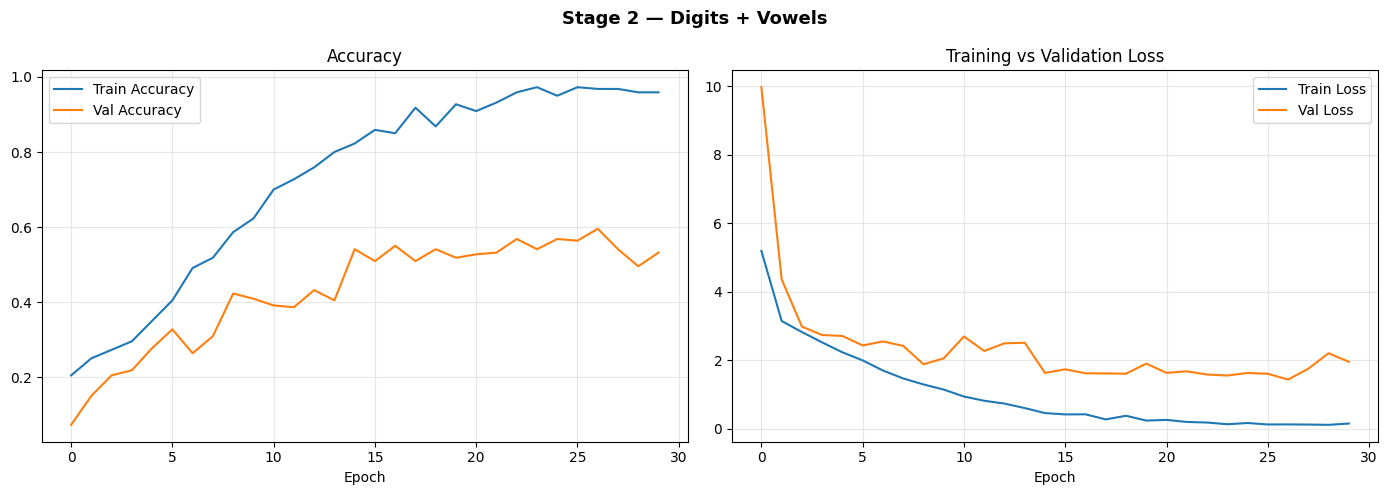

Stage 2 complete. Model saved.


In [12]:
print("=" * 60)
print("STAGE 2: Expanding to DIGITS + VOWELS (22 classes)")
print("=" * 60)

STAGE2_CLASSES = DIGITS + VOWELS

train_ds_s2 = build_tf_dataset(TRAIN_DIR, STAGE2_CLASSES, BIN_METHOD,
                                shuffle=True, augment=True)
val_ds_s2   = build_tf_dataset(TEST_DIR,  STAGE2_CLASSES, BIN_METHOD,
                                shuffle=False, augment=False)

# Unfreeze last 30 layers for finer tuning
unfreeze_layers(model, unfreeze_from=-30)
model = compile_model(model, learning_rate=5e-4)

hist_s2 = model.fit(
    train_ds_s2,
    validation_data=val_ds_s2,
    epochs=EPOCHS_STAGE2,
    callbacks=get_callbacks(BASE_MODEL_NAME, "stage2"),
)

plot_history(hist_s2, "Stage 2 — Digits + Vowels",
             RESULTS_DIR / f"{BASE_MODEL_NAME}_{BIN_METHOD}_stage2.png")

model.save(MODELS_DIR / f"{BASE_MODEL_NAME}_{BIN_METHOD}_stage2.h5")
print("Stage 2 complete. Model saved.")

### 4.5 Stage 3 — Full 57-Class Training

In [35]:
model = build_hybrid_model(BASE_MODEL_NAME, NUM_CLASSES, freeze_base=True)
model = compile_model(model, learning_rate=1e-3)

print("=" * 60)
print("STAGE 3: Full training — ALL 57 CLASSES")
print("=" * 60)

train_ds_s3 = build_tf_dataset(TRAIN_DIR, ALL_CLASSES, BIN_METHOD,
                                shuffle=True, augment=True)
val_ds_s3   = build_tf_dataset(TEST_DIR,  ALL_CLASSES, BIN_METHOD,
                                shuffle=False, augment=False)

# Unfreeze entire network for full fine-tuning
for layer in model.layers:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True
print(f"All layers unfrozen. Trainable params: {sum(p.numpy().size for p in model.trainable_variables):,}")

model = compile_model(model, learning_rate=1e-4)

hist_s3 = model.fit(
    train_ds_s3,
    validation_data=val_ds_s3,
    epochs=EPOCHS_STAGE3,
    callbacks=get_callbacks(BASE_MODEL_NAME, "stage3"),
)

plot_history(hist_s3, "Stage 3 — Full 57-Class Training",
             RESULTS_DIR / f"{BASE_MODEL_NAME}_{BIN_METHOD}_stage3.png")

model.save(MODELS_DIR / f"{BASE_MODEL_NAME}_{BIN_METHOD}_final.h5")
print("Stage 3 complete. Final model saved.")

STAGE 3: Full training — ALL 57 CLASSES
  [train] 1,140 images | 57 classes | method=tozero
  [test] 1,140 images | 57 classes | method=tozero
All layers unfrozen. Trainable params: 60,124,921
Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.0173 - loss: 4.0443
Epoch 1: val_accuracy improved from None to 0.01754, saving model to MODI_HChar\models\ResNet152_stage3_best.h5



Epoch 1: finished saving model to MODI_HChar\models\ResNet152_stage3_best.h5
36/36 ━━━━━━━━━━━━━━━━━━━━ 321s 8s/step - accuracy: 0.0167 - loss: 4.0435 - val_accuracy: 0.0175 - val_loss: 4.1552 - learning_rate: 1.0000e-04
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.0138 - loss: 4.0431
Epoch 2: val_accuracy did not improve from 0.01754
36/36 ━━━━━━━━━━━━━━━━━━━━ 259s 7s/step - accuracy: 0.0140 - loss: 4.0432 - val_accuracy: 0.0175 - val_loss: 4.3248 - learning_rate: 1.0000e-04
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.0121 - loss: 4.0430
Epoch 3: val_accuracy did not improve from 0.01754
36/36 ━━━━━━━━━━━━━━━━━━━━ 253s 7s/step - accuracy: 0.0105 - loss: 4.0432 - val_accuracy: 0.0175 - val_loss: 4.2424 - learning_rate: 1.0000e-04
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.0158 - loss: 4.0430
Epoch 4: val_accuracy did not improve from 0.01754
36/36 ━━━━━━━━━━━━━━━━━━━━ 256s 7s/step - accuracy: 0.0175 - loss: 4.0431 - val_accuracy

KeyboardInterrupt: 

---
## Phase 5: Evaluation & Validation

### 5.1 Per-Binarization Performance Metrics (Table 2 / Table 7 replication)

In [27]:
import tensorflow as tf
from tensorflow import keras

@keras.utils.register_keras_serializable()
class CustomScaleLayer(keras.layers.Layer):
    def __init__(self, scale, **kwargs):
        super().__init__(**kwargs)
        self.scale = scale

    def call(self, inputs):
        # inputs is a list of two tensors: [x, scale_tensor]
        return inputs[0] * inputs[1]

    def get_config(self):
        config = super().get_config()
        config.update({"scale": self.scale})
        return config

In [29]:
def evaluate_model_on_method(
    model_path: str,
    binarize_method: str,
    class_list: list = ALL_CLASSES,
) -> dict:
    """
    Load a saved model, run inference on the test split with the given
    binarization method, and return accuracy / precision / loss.
    """
    mdl = keras.models.load_model(model_path,custom_objects={"CustomScaleLayer": CustomScaleLayer})
    test_ds = build_tf_dataset(TEST_DIR, class_list, binarize_method,
                                shuffle=False, augment=False)

    loss, acc = mdl.evaluate(test_ds, verbose=0)

    # Collect predictions for precision
    y_true, y_pred = [], []
    for imgs, lbls in test_ds:
        preds = mdl.predict(imgs, verbose=0)
        y_true.extend(lbls.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    from sklearn.metrics import precision_score
    precision = precision_score(y_true, y_pred, average='weighted',
                                zero_division=0)

    return {
        "method":    binarize_method,
        "accuracy":  acc,
        "precision": precision,
        "loss":      loss,
        "y_true":    y_true,
        "y_pred":    y_pred,
    }


# Evaluate the final model across all three binarization methods
final_model_path = str(MODELS_DIR / f"{BASE_MODEL_NAME}_{BIN_METHOD}_final.h5")

results = {}
# for method in ["otsu", "sauvola", "tozero"]:
for method in ["tozero"]:
    print(f"\nEvaluating with {method} binarization...")
    results[method] = evaluate_model_on_method(final_model_path, method)

# Summary table
print("\n" + "=" * 55)
print(f"{'Method':<12} {'Accuracy':>12} {'Precision':>12} {'Loss':>10}")
print("=" * 55)
for m, r in results.items():
    print(f"{m:<12} {r['accuracy']:>11.4f}  {r['precision']:>11.4f}  {r['loss']:>9.4f}")
print("=" * 55)


Evaluating with tozero binarization...


  [test] 1,140 images | 57 classes | method=tozero

Method           Accuracy    Precision       Loss
tozero            0.0175       0.0003    14.4174


### 5.2 All-Model Comparison Table

In [ ]:
# ── If you trained all three base models, load and compare ────────────────────
# (This cell is a template; run it after training each model variant)

import pandas as pd

comparison_rows = []
for base in ["InceptionV3", "ResNet152", "InceptionResNetV2"]:
    for method in ["otsu", "sauvola", "tozero"]:
        ckpt = MODELS_DIR / f"{base}_{method}_final.h5"
        if ckpt.exists():
            r = evaluate_model_on_method(str(ckpt), method)
            comparison_rows.append({
                "Model":     base,
                "Method":    method,
                "Accuracy":  round(r['accuracy'], 4),
                "Precision": round(r['precision'], 4),
                "Loss":      round(r['loss'], 4),
            })
        else:
            comparison_rows.append({
                "Model":     base,
                "Method":    method,
                "Accuracy":  "not trained",
                "Precision": "—",
                "Loss":      "—",
            })

df_comparison = pd.DataFrame(comparison_rows)
display(df_comparison)
df_comparison.to_csv(RESULTS_DIR / "all_model_comparison.csv", index=False)
print("Saved to results/all_model_comparison.csv")

### 5.3 Confusion Matrix — Full 57 Classes

In [ ]:
best_result = results[BIN_METHOD]   # Use method trained with
y_true = best_result["y_true"]
y_pred = best_result["y_pred"]

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(22, 20))
sns.heatmap(
    cm,
    xticklabels=ALL_CLASSES,
    yticklabels=ALL_CLASSES,
    cmap='Blues',
    fmt='d',
    annot=(NUM_CLASSES <= 30),   # only annotate cells if manageable
    ax=ax,
)
ax.set_title(f"Confusion Matrix — {BASE_MODEL_NAME} + {BIN_METHOD}",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=150)
plt.show()

### 5.4 Error Analysis — 'sa' vs 'na' Confusion

In [ ]:
TARGET_PAIRS = [("sa", "na"), ("sha", "na"), ("sa", "sha")]

print("─" * 55)
print("Error Analysis: Visually Similar Character Pairs")
print("─" * 55)

for cls_a, cls_b in TARGET_PAIRS:
    if cls_a not in CLASS_TO_IDX or cls_b not in CLASS_TO_IDX:
        print(f"  '{cls_a}' or '{cls_b}' not in class map — skipping.")
        continue

    idx_a, idx_b = CLASS_TO_IDX[cls_a], CLASS_TO_IDX[cls_b]

    # Indices in y_true belonging to cls_a
    a_samples = [i for i, t in enumerate(y_true) if t == idx_a]
    b_samples = [i for i, t in enumerate(y_true) if t == idx_b]

    a_correct   = sum(1 for i in a_samples if y_pred[i] == idx_a)
    a_as_b      = sum(1 for i in a_samples if y_pred[i] == idx_b)
    b_correct   = sum(1 for i in b_samples if y_pred[i] == idx_b)
    b_as_a      = sum(1 for i in b_samples if y_pred[i] == idx_a)

    print(f"\n  Pair: '{cls_a}' ↔ '{cls_b}'")
    print(f"    '{cls_a}' correctly classified : {a_correct}/{len(a_samples)} "
          f"({100*a_correct/max(len(a_samples),1):.1f}%)")
    print(f"    '{cls_a}' misclassified as '{cls_b}' : {a_as_b} "
          f"({100*a_as_b/max(len(a_samples),1):.1f}%)")
    print(f"    '{cls_b}' correctly classified : {b_correct}/{len(b_samples)} "
          f"({100*b_correct/max(len(b_samples),1):.1f}%)")
    print(f"    '{cls_b}' misclassified as '{cls_a}' : {b_as_a} "
          f"({100*b_as_a/max(len(b_samples),1):.1f}%)")

print("\n" + "─" * 55)

### 5.5 Per-Class Accuracy Bar Chart

In [ ]:
from sklearn.metrics import classification_report
import json

report = classification_report(
    y_true, y_pred,
    target_names=ALL_CLASSES,
    output_dict=True,
    zero_division=0,
)

per_class_acc = {cls: report[cls]['recall'] for cls in ALL_CLASSES if cls in report}

fig, ax = plt.subplots(figsize=(20, 6))
colors = [
    '#4e79a7' if c in DIGITS
    else '#f28e2b' if c in VOWELS
    else '#59a14f'
    for c in per_class_acc
]
ax.bar(per_class_acc.keys(), per_class_acc.values(), color=colors)
ax.axhline(y=0.90, color='red', linestyle='--', alpha=0.6, label='90% threshold')
ax.set_xticklabels(per_class_acc.keys(), rotation=90, fontsize=9)
ax.set_ylabel("Per-Class Recall")
ax.set_title(f"Per-Class Accuracy — {BASE_MODEL_NAME} + {BIN_METHOD}")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4e79a7', label='Digits'),
    Patch(facecolor='#f28e2b', label='Vowels'),
    Patch(facecolor='#59a14f', label='Consonants'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig(RESULTS_DIR / "per_class_accuracy.png", dpi=150)
plt.show()

# Save full report
with open(RESULTS_DIR / "classification_report.json", "w") as f:
    json.dump(report, f, indent=2)
print("Full classification report saved.")

### 5.6 Final Summary

In [ ]:
print("\n" + "═" * 60)
print(" MODI-HChar Experiment Summary")
print("═" * 60)
print(f" Base model     : {BASE_MODEL_NAME}")
print(f" Binarization   : {BIN_METHOD}")
print(f" Total classes  : {NUM_CLASSES}")
print(f" Image size     : {TARGET_SIZE[0]}×{TARGET_SIZE[1]}")
print()

for method, r in results.items():
    print(f" [{method.upper():<8}] "
          f"Acc={r['accuracy']:.4f}  "
          f"Prec={r['precision']:.4f}  "
          f"Loss={r['loss']:.4f}")

best_method = max(results, key=lambda m: results[m]['accuracy'])
print(f"\n Best method by accuracy: {best_method.upper()} "
      f"({results[best_method]['accuracy']:.4f})")
print("═" * 60)
print(f"\n Outputs saved to: {RESULTS_DIR.resolve()}")
print(f" Models saved to : {MODELS_DIR.resolve()}")